# Lesson 13: Advanced Designs: Clustering and Time-to-Event Outcomes

**Course:** hypothesis_testing_and_statistical_inference  
**Prerequisites:** Basic Python and descriptive statistics

This lesson follows a repeatable workflow: define the question, encode the design,
check assumptions, estimate the effect, quantify uncertainty, test the claim, and
communicate both statistical and practical meaning.


## Learning objectives

1. Recognize pseudo-replication caused by clustered observations
2. Fit and interpret a random-intercept mixed model
3. Explain censoring and compare survival curves with a log-rank test
4. Know when specialist methods are required instead of a basic test


## Setup

Run this cell first. Every example uses a fixed random seed so results are reproducible.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Work whether the kernel starts in the course root or a level folder.
working_dir = Path.cwd()
COURSE_ROOT = working_dir if (working_dir / "data").exists() else working_dir.parent
DATA_DIR = COURSE_ROOT / "data"

rng = np.random.default_rng(20260920)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.precision", 4)


## 13.1 Clustered and longitudinal data

The Grunfeld investment data contain 20 yearly observations for each of 11 firms. Rows from the same firm are correlated,
so treating all 220 rows as independent would understate uncertainty. A random-intercept model represents firm-specific
baselines while estimating change over time.


In [2]:
import statsmodels.formula.api as smf

longitudinal = pd.read_csv(DATA_DIR / "grunfeld_investment.csv")
longitudinal["year_centered"] = longitudinal["year"]-longitudinal["year"].min()
firm_mean_value = longitudinal.groupby("firm")["market_value"].transform("mean")
longitudinal["large_firm"] = (firm_mean_value >= firm_mean_value.median()).astype(int)
longitudinal["log_investment"] = np.log1p(longitudinal["investment"])

mixed = smf.mixedlm("log_investment ~ year_centered * large_firm", longitudinal,
                    groups=longitudinal["firm"]).fit()
mixed.summary().tables[1]


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,2.617,0.524,4.998,0.000,1.591,3.643
year_centered,0.039,0.005,8.511,0.000,0.030,0.048
large_firm,1.554,0.709,2.193,0.028,0.165,2.944
year_centered:large_firm,0.026,0.006,4.154,0.000,0.014,0.038
Group Var,1.358,2.472,,,,


## 13.2 Time-to-event data and censoring

The heart-transplant dataset records follow-up days, age, and whether death was observed. A censored patient contributes
information up to the last known follow-up time. The log-rank test compares observed and expected events across age-group
risk sets; the age groups are derived for teaching and were not randomized.


In [3]:
def logrank_two_sample(time, event, group):
    event_times = np.sort(np.unique(time[event == 1]))
    observed_1 = expected_1 = variance = 0.0
    for t in event_times:
        at_risk = time >= t
        n1 = np.sum(at_risk & (group == 1)); n0 = np.sum(at_risk & (group == 0))
        d1 = np.sum((time == t) & (event == 1) & (group == 1))
        d0 = np.sum((time == t) & (event == 1) & (group == 0))
        n, d = n1+n0, d1+d0
        if n <= 1:
            continue
        observed_1 += d1
        expected_1 += d*n1/n
        variance += (n1*n0*d*(n-d))/(n**2*(n-1))
    chi2 = (observed_1-expected_1)**2/variance
    return chi2, stats.chi2.sf(chi2, 1)

heart = pd.read_csv(DATA_DIR / "heart_transplant_survival.csv")
time = heart["survival_days"].to_numpy()
event = heart["event_observed"].to_numpy()
group = (heart["age_group"] == "48 or older").astype(int).to_numpy()
lr_chi2, lr_p = logrank_two_sample(time, event, group)
pd.Series({"patients": len(heart), "events": event.sum(), "censored": len(heart)-event.sum(),
           "log-rank chi-square": lr_chi2, "p": lr_p})


patients               69.0000
events                 45.0000
censored               24.0000
log-rank chi-square     2.6220
p                       0.1054
dtype: float64

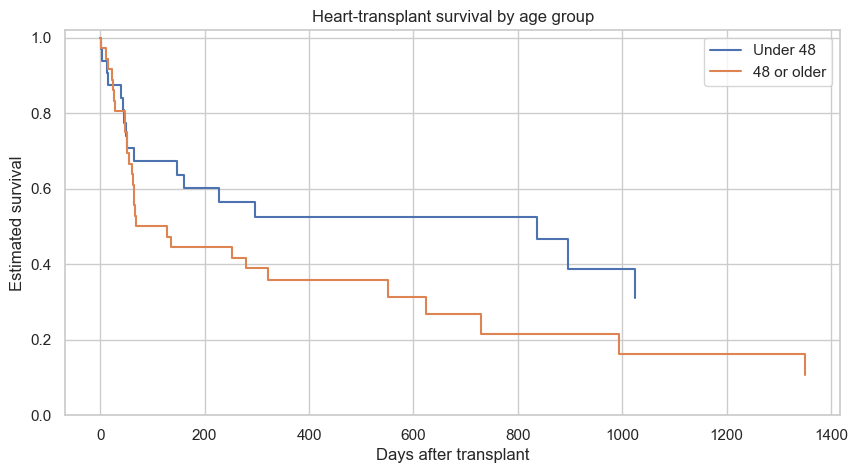

In [4]:
def km_curve(time, event):
    times = np.sort(np.unique(time[event == 1]))
    survival = 1.0
    xs, ys = [0.0], [1.0]
    for t in times:
        n_risk = np.sum(time >= t)
        d = np.sum((time == t) & (event == 1))
        survival *= (1-d/n_risk)
        xs.extend([t, t]); ys.extend([ys[-1], survival])
    return xs, ys

fig, ax = plt.subplots()
for label, g in [("Under 48", 0), ("48 or older", 1)]:
    xg, yg = km_curve(time[group == g], event[group == g])
    ax.step(xg, yg, where="post", label=label)
ax.set(xlabel="Days after transplant", ylabel="Estimated survival", ylim=(0, 1.02),
       title="Heart-transplant survival by age group")
ax.legend(); plt.show()


## Worked example and interpretation

### Correlation within firms

The Grunfeld data contain 220 yearly records from 11 firms. A random-intercept mixed model lets each firm have its own baseline log-investment level while estimating time, a derived large-firm indicator, and their interaction. The fitted baseline time slope is 0.039 log units per year; the large-firm interaction adds about 0.026 log units per year under the model. These conditional slopes describe associations in historical panel data. The firm, rather than each row, is the independent cluster for uncertainty; treating all 220 rows as unrelated would overstate information. The large-firm label is derived from observed market value, so its coefficient is not a randomized treatment effect.

### Censored follow-up

The heart-transplant example has 69 patients, 45 recorded events, and 24 censored follow-ups. The hand-built log-rank calculation compares age groups at observed event times using the number still at risk; it gives chi-square = 2.622 and p = 0.105. The Kaplan–Meier steps update estimated survival only at events while censored patients contribute information up to their last follow-up. A non-significant comparison does not establish identical survival curves. Interpretation requires credible censoring and group definitions, and applied survival work should use validated routines with uncertainty bands and appropriate tie handling.

## Practice and solution

**Practice.** A trial randomizes 20 clinics, then measures 50 patients per clinic. Is $n=1000$ for an
ordinary independent t-test?

<details><summary>Solution</summary>

No. Treatment was randomized at the clinic level and patients within clinics are correlated. The design
has 20 independent clusters. Use a cluster-aware analysis—such as a clinic-level comparison, mixed
model, GEE, or cluster-randomization method—and plan power using the intraclass correlation.
</details>

## Key takeaways

- The independent unit is determined by sampling and randomization, not the number of rows.
- Censoring requires survival methods.
- Advanced tests should be chosen with domain and design expertise.


## Reproducibility checklist

- State the population, outcome, groups, and sampling unit.
- State $H_0$, $H_1$, alpha, and whether the test is one- or two-sided before looking at results.
- Verify independence from the design; use plots and diagnostics for distributional assumptions.
- Report the estimate, confidence interval, effect size, test statistic, degrees of freedom, and exact p-value.
- Separate statistical evidence from practical importance and acknowledge design limitations.
